# Exploratory Data Analysis — Companies & Job Metadata Tables

**Scope:** everything except `postings.csv` (covered separately in `02_eda_postings.ipynb`): all four `companies/` tables, all four `jobs/` tables, and the two `mappings/` lookup tables.

**Goal:** understand shape, quality, and — critically — **how well each table actually joins back to `postings.csv`**, since that determines how much of each table we can actually use. No cleaning or modeling here, same as the postings notebook.

## TL;DR

- **Every secondary table is internally clean** — no full-row duplicates anywhere across all eight tables.
- **Join coverage varies a lot.** `job_skills` and `job_industries` cover ~99% of postings. `salaries` and `benefits` only cover 29.1% and 23.2% respectively — most postings have no benefits/salary detail beyond what's already in `postings.csv`.
- **`jobs/salaries.csv` may be a better salary source than `postings.csv`'s own salary columns** — it has less missingness on `min_salary`/`max_salary` (16.8% vs 75.9%). Worth comparing the two rather than assuming `postings.csv` is authoritative.
- **`company_size` and `country` use placeholder values instead of true nulls** — e.g. `country == "0"` for 727 companies, which `.isna()` won't catch. This will silently break any groupby on those columns if not handled.
- **`job_skills.csv` references 4,711 job_ids that don't exist in `postings.csv`** — likely postings that were later removed from the main export. These rows are unusable for our pipeline.
- **`company_specialities.csv` only covers 72.7% of companies** (17,780 / 24,473) — a real gap if we want to use specialties as a feature.

Nothing has been dropped, imputed, or transformed. Open questions are in the final section.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

BASE = "./"

# postings.csv job_id / company_id are the join keys everything else gets checked against
postings_keys = pd.read_csv(f"{BASE}postings.csv", usecols=["job_id", "company_id"])
posting_job_ids = set(postings_keys["job_id"])
posting_company_ids = set(postings_keys["company_id"].dropna())
N_POSTINGS = len(postings_keys)
print(f"postings.csv: {N_POSTINGS:,} rows, {len(posting_company_ids):,} distinct non-null company_id")

postings.csv: 123,849 rows, 24,474 distinct non-null company_id


A small helper so every table's join coverage is checked the same way: what fraction of `postings.csv` rows have a match in this table?

In [2]:
def profile(df, name):
    """Print shape, dtypes, full-row duplicate count, and missingness for a table."""
    print(f"--- {name} ---")
    print(f"shape: {df.shape}")
    dupes = df.duplicated(keep=False).sum()
    print(f"full-row duplicates: {dupes:,}")
    missing = (df.isna().mean() * 100).round(1)
    missing = missing[missing > 0].sort_values(ascending=False)
    print("missing % (only columns with gaps):")
    print(missing if len(missing) else "  none")

def job_id_coverage(df, name):
    matched = len(posting_job_ids & set(df["job_id"]))
    print(f"{name}: {matched:,} / {N_POSTINGS:,} postings have a match ({matched/N_POSTINGS*100:.1f}%)")
    orphans = set(df["job_id"]) - posting_job_ids
    if orphans:
        print(f"  ({len(orphans):,} job_id values in this table do NOT exist in postings.csv)")

## 2. `companies/companies.csv`

One row per company: size, location, description. This is the table `postings.csv`'s `company_id` joins against.

In [3]:
companies = pd.read_csv(f"{BASE}companies/companies.csv")
profile(companies, "companies.csv")
companies.head()

--- companies.csv ---
shape: (24473, 10)
full-row duplicates: 0
missing % (only columns with gaps):
company_size    11.3
description      1.2
state            0.1
zip_code         0.1
address          0.1
dtype: float64


,company_id,name,description,company_size,state,country,city,zip_code,address,url
0,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm
1,1016,GE HealthCare,Every day millions of people feel the impact o...,7.0,0,US,Chicago,0,-,https://www.linkedin.com/company/gehealthcare
2,1025,Hewlett Packard Enterprise,Official LinkedIn of Hewlett Packard Enterpris...,7.0,Texas,US,Houston,77389,1701 E Mossy Oaks Rd Spring,https://www.linkedin.com/company/hewlett-packa...
3,1028,Oracle,We’re a cloud technology company that provides...,7.0,Texas,US,Austin,78741,2300 Oracle Way,https://www.linkedin.com/company/oracle
4,1033,Accenture,Accenture is a leading global professional ser...,7.0,0,IE,Dublin 2,0,Grand Canal Harbour,https://www.linkedin.com/company/accenture


In [4]:
matched = len(posting_company_ids & set(companies["company_id"]))
print(f"company_id coverage: {matched:,} / {len(posting_company_ids):,} distinct company_ids in postings.csv matched ({matched/len(posting_company_ids)*100:.1f}%)")

company_id coverage: 24,473 / 24,474 distinct company_ids in postings.csv matched (100.0%)


`company_size` is an ordinal code (1–7, LinkedIn's own size bucket), not free text — worth checking its distribution and, separately, whether `country`/`state`/`zip_code` use real nulls or placeholder values, since the sample row we looked at earlier had `state="0"` and `address="-"` instead of blank.

In [5]:
print("company_size distribution:")
print(companies["company_size"].value_counts(dropna=False).sort_index())
print()
print("top countries:")
print(companies["country"].value_counts().head(8))

company_size distribution:
company_size
1.0    4348
2.0    4956
3.0    3108
4.0    2333
5.0    3918
6.0    1083
7.0    1953
NaN    2774
Name: count, dtype: int64

top countries:
country
US    21635
0       727
GB      620
CA      258
IN      157
DE      128
FR      118
CH       93
Name: count, dtype: int64


**Open question flag:** `country` includes a literal `"0"` value (727 rows) alongside real country codes — this is a placeholder, not a true missing value, and `.isna()` above would not have caught it. Same pattern likely applies to `state`, `city`, `zip_code`, and `address`. We should check all of these for placeholder values before treating `companies.csv` missingness numbers as complete.

## 3. `companies/company_industries.csv`

Maps each company to a single industry label (free text, not the numeric `mappings/industries.csv` codes).

In [6]:
company_industries = pd.read_csv(f"{BASE}companies/company_industries.csv")
profile(company_industries, "company_industries.csv")

coverage = company_industries["company_id"].nunique()
print(f"\ncompany coverage: {coverage:,} / {len(companies):,} companies have an industry ({coverage/len(companies)*100:.1f}%)")
print()
print("top industries:")
print(company_industries["industry"].value_counts().head(10))

--- company_industries.csv ---
shape: (24375, 2)
full-row duplicates: 0
missing % (only columns with gaps):
  none

company coverage: 24,365 / 24,473 companies have an industry (99.6%)

top industries:
industry
Staffing and Recruiting             2387
IT Services and IT Consulting       2130
Hospitals and Health Care           1673
Software Development                1440
Financial Services                   986
Construction                         752
Advertising Services                 624
Non-profit Organizations             617
Real Estate                          545
Business Consulting and Services     498
Name: count, dtype: int64


## 4. `companies/company_specialities.csv`

Many-to-many: companies can list multiple specialities (free-text tags companies self-report on LinkedIn).

In [7]:
company_specialities = pd.read_csv(f"{BASE}companies/company_specialities.csv")
profile(company_specialities, "company_specialities.csv")

coverage = company_specialities["company_id"].nunique()
avg_per_company = len(company_specialities) / coverage
print(f"\ncompany coverage: {coverage:,} / {len(companies):,} companies have at least one speciality ({coverage/len(companies)*100:.1f}%)")
print(f"average specialities per covered company: {avg_per_company:.1f}")
print()
print("top specialities:")
print(company_specialities["speciality"].value_counts().head(10))

--- company_specialities.csv ---
shape: (169387, 2)


full-row duplicates: 0
missing % (only columns with gaps):
  none

company coverage: 17,780 / 24,473 companies have at least one speciality (72.7%)
average specialities per covered company: 9.5

top specialities:
speciality
Engineering               601
Recruiting                581
Staffing                  578
Technology                529
Consulting                492
Healthcare                445
Manufacturing             420
Marketing                 416
Project Management        379
Information Technology    376
Name: count, dtype: int64


## 5. `companies/employee_counts.csv`

This one is different from the others: it's a **time-series snapshot table**, not a one-row-per-company lookup. Some companies have up to 13 recorded snapshots (`time_recorded`), so `company_id` repeating here is expected, not a data quality problem — worth confirming before assuming it should be deduplicated.

In [8]:
employee_counts = pd.read_csv(f"{BASE}companies/employee_counts.csv")
profile(employee_counts, "employee_counts.csv")

print(f"\nunique company_id: {employee_counts['company_id'].nunique():,} vs {len(employee_counts):,} total rows")
print("snapshots per company (top 5 most-tracked):")
print(employee_counts["company_id"].value_counts().head())

--- employee_counts.csv ---
shape: (35787, 4)
full-row duplicates: 0
missing % (only columns with gaps):
  none

unique company_id: 24,473 vs 35,787 total rows
snapshots per company (top 5 most-tracked):
company_id
5235        13
33242739    13
1681        12
79383535    12
11056       11
Name: count, dtype: int64


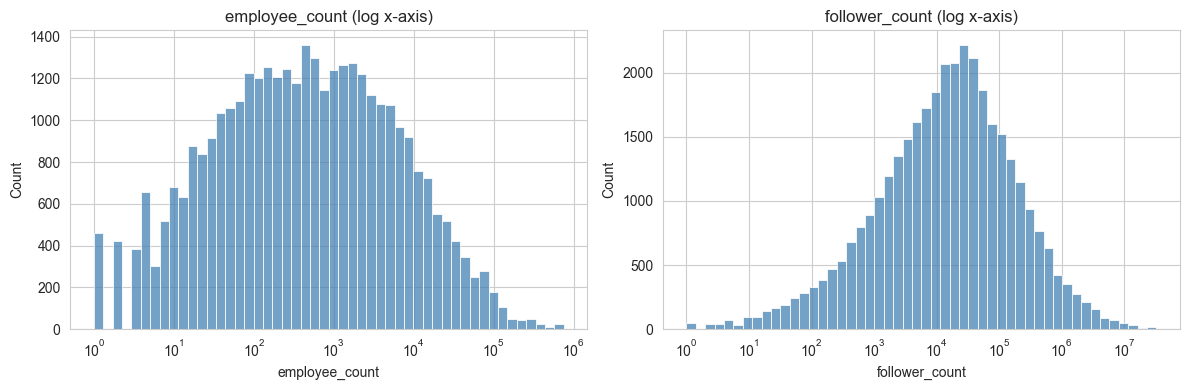

,employee_count,follower_count
count,35787.000000,3.578700e+04
mean,6715.874256,2.012616e+05
std,29400.984643,1.114733e+06
min,0.000000,0.000000e+00
25%,56.000000,2.738000e+03
50%,418.000000,1.617800e+04
75%,2945.000000,7.412950e+04
max,751125.000000,3.270284e+07


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(employee_counts["employee_count"], bins=50, ax=axes[0], color="steelblue", log_scale=(True, False))
axes[0].set_title("employee_count (log x-axis)")

sns.histplot(employee_counts["follower_count"], bins=50, ax=axes[1], color="steelblue", log_scale=(True, False))
axes[1].set_title("follower_count (log x-axis)")

plt.tight_layout()
plt.show()

employee_counts[["employee_count", "follower_count"]].describe()

Both `employee_count` and `follower_count` are heavily right-skewed (means far above medians), plotted here on a log x-axis just to see the shape — no transformation has been applied to the underlying data.

## 6. `mappings/skills.csv` and `mappings/industries.csv`

These are small controlled vocabularies, not fact tables — just lookup codes. Shown in full rather than profiled like the tables above.

In [10]:
skills_map = pd.read_csv(f"{BASE}mappings/skills.csv")
industries_map = pd.read_csv(f"{BASE}mappings/industries.csv")

print(f"skills.csv: {skills_map.shape[0]} skill categories")
print(f"industries.csv: {industries_map.shape[0]} industry codes")
skills_map

skills.csv: 35 skill categories
industries.csv: 422 industry codes


,skill_abr,skill_name
0,ART,Art/Creative
1,DSGN,Design
2,ADVR,Advertising
3,PRDM,Product Management
4,DIST,Distribution
5,EDU,Education
6,TRNG,Training
7,PRJM,Project Management
8,CNSL,Consulting
9,PRCH,Purchasing


## 7. `jobs/job_skills.csv`

Many-to-many: maps `job_id` to one of the 35 broad `skill_abr` categories from `mappings/skills.csv`. As noted in the postings notebook, these are functional categories ("Engineering", "Sales"), not granular skills — real skill extraction still has to come from `description` text.

In [11]:
job_skills = pd.read_csv(f"{BASE}jobs/job_skills.csv")
profile(job_skills, "job_skills.csv")
print()
job_id_coverage(job_skills, "job_skills")

avg_skills = len(job_skills) / job_skills["job_id"].nunique()
print(f"average skill tags per covered job: {avg_skills:.2f}")

--- job_skills.csv ---
shape: (213768, 2)
full-row duplicates: 0
missing % (only columns with gaps):
  none



job_skills: 122,096 / 123,849 postings have a match (98.6%)
  (4,711 job_id values in this table do NOT exist in postings.csv)
average skill tags per covered job: 1.69


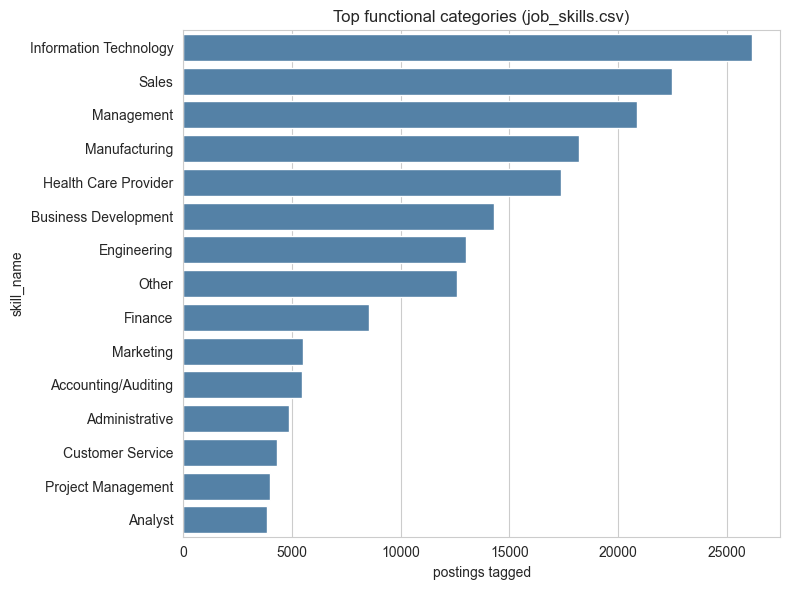

In [12]:
skills_joined = job_skills.merge(skills_map, on="skill_abr", how="left")
top_skills = skills_joined["skill_name"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_skills.values, y=top_skills.index, ax=ax, color="steelblue")
ax.set_xlabel("postings tagged")
ax.set_title("Top functional categories (job_skills.csv)")
plt.tight_layout()
plt.show()

## 8. `jobs/job_industries.csv`

Maps `job_id` to `industry_id` (joins to `mappings/industries.csv`, 422 categories — much finer-grained than the 35 skill categories).

In [13]:
job_industries = pd.read_csv(f"{BASE}jobs/job_industries.csv")
profile(job_industries, "job_industries.csv")
print()
job_id_coverage(job_industries, "job_industries")

--- job_industries.csv ---
shape: (164808, 2)
full-row duplicates: 0
missing % (only columns with gaps):
  none

job_industries: 122,413 / 123,849 postings have a match (98.8%)
  (4,712 job_id values in this table do NOT exist in postings.csv)


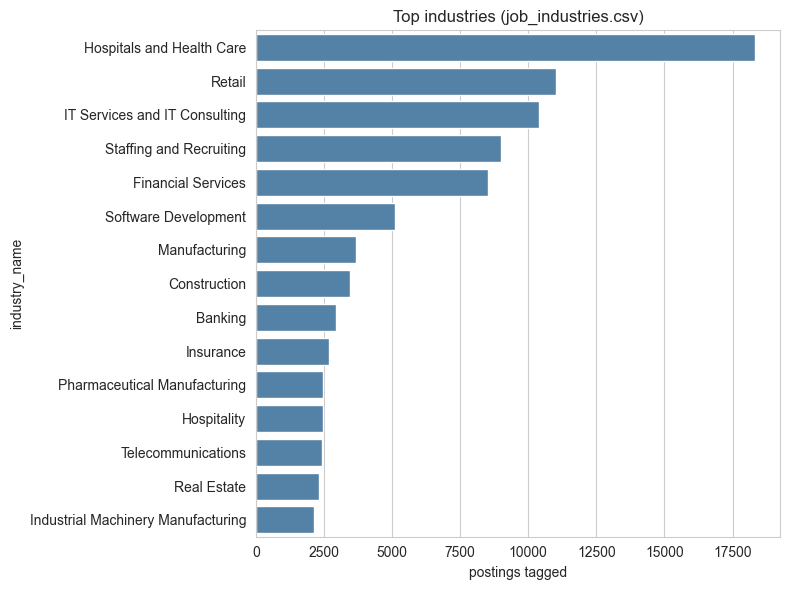

In [14]:
industries_joined = job_industries.merge(industries_map, on="industry_id", how="left")
top_industries = industries_joined["industry_name"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_industries.values, y=top_industries.index, ax=ax, color="steelblue")
ax.set_xlabel("postings tagged")
ax.set_title("Top industries (job_industries.csv)")
plt.tight_layout()
plt.show()

## 9. `jobs/salaries.csv`

One row per `job_id` (unlike the many-to-many tables above). Worth comparing against the salary columns already inside `postings.csv` — they may not be the same completeness.

In [15]:
salaries = pd.read_csv(f"{BASE}jobs/salaries.csv")
profile(salaries, "salaries.csv")
print()
job_id_coverage(salaries, "salaries")
print(f"\nunique job_id: {salaries['job_id'].nunique():,} vs {len(salaries):,} rows (one salary record per job)")

--- salaries.csv ---
shape: (40785, 8)
full-row duplicates: 0
missing % (only columns with gaps):
med_salary    83.2
max_salary    16.8
min_salary    16.8
dtype: float64

salaries: 36,073 / 123,849 postings have a match (29.1%)
  (4,712 job_id values in this table do NOT exist in postings.csv)

unique job_id: 40,785 vs 40,785 rows (one salary record per job)


**Open question flag:** `salaries.csv` has only 16.8% missing on `min_salary`/`max_salary`, versus 75.9% missing for the same fields directly in `postings.csv`. Before building any salary feature, we should check whether these two sources agree where they overlap, and if `salaries.csv` is simply more complete — in which case it may be the better source to use instead of (or merged with) the postings columns.

## 10. `jobs/benefits.csv`

Many-to-many: a job can list multiple benefit types. Includes an `inferred` flag whose meaning isn't self-evident from the column name alone.

In [16]:
benefits = pd.read_csv(f"{BASE}jobs/benefits.csv")
profile(benefits, "benefits.csv")
print()
job_id_coverage(benefits, "benefits")

avg_benefits = len(benefits) / benefits["job_id"].nunique()
print(f"average benefit types per covered job: {avg_benefits:.2f}")
print(f"\n'inferred' value counts: {benefits['inferred'].value_counts().to_dict()}")

--- benefits.csv ---
shape: (67943, 3)
full-row duplicates: 0
missing % (only columns with gaps):
  none

benefits: 28,735 / 123,849 postings have a match (23.2%)
  (1,288 job_id values in this table do NOT exist in postings.csv)
average benefit types per covered job: 2.26

'inferred' value counts: {1: 40424, 0: 27519}


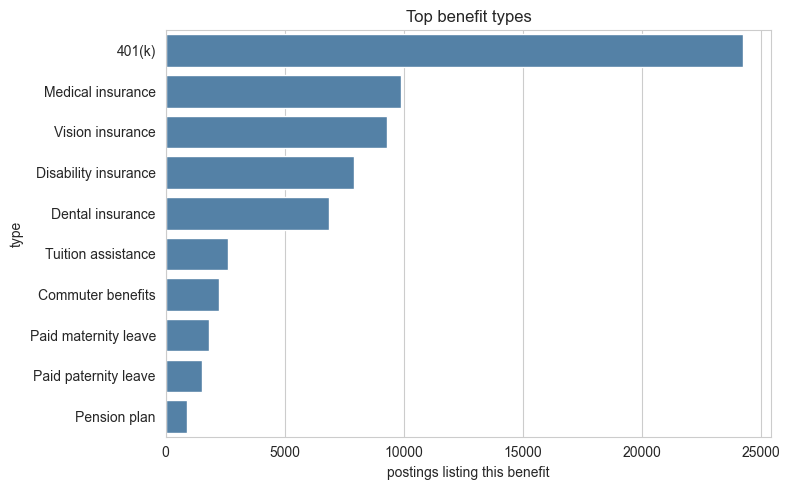

In [17]:
top_benefits = benefits["type"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_benefits.values, y=top_benefits.index, ax=ax, color="steelblue")
ax.set_xlabel("postings listing this benefit")
ax.set_title("Top benefit types")
plt.tight_layout()
plt.show()

**Open question flag:** roughly 60% of benefit records have `inferred == 1`. We don't yet know if that means "LinkedIn inferred this benefit from the job description" vs. "employer explicitly listed it" — that distinction could matter if we treat benefits as a feature, since inferred values are presumably less reliable than explicit ones.

## 11. Join coverage summary

The single most useful number from this notebook for planning the recommendation pipeline: what fraction of the 123,849 postings actually have data in each secondary table.

In [18]:
coverage_summary = pd.DataFrame({
    "table": ["job_skills", "job_industries", "salaries", "benefits"],
    "postings_matched": [
        len(posting_job_ids & set(job_skills["job_id"])),
        len(posting_job_ids & set(job_industries["job_id"])),
        len(posting_job_ids & set(salaries["job_id"])),
        len(posting_job_ids & set(benefits["job_id"])),
    ],
})
coverage_summary["pct_of_postings"] = (coverage_summary["postings_matched"] / N_POSTINGS * 100).round(1)
coverage_summary

,table,postings_matched,pct_of_postings
0,job_skills,122096,98.6
1,job_industries,122413,98.8
2,salaries,36073,29.1
3,benefits,28735,23.2


## 12. Summary of open questions

Nothing has been dropped, imputed, joined, or transformed in this notebook — observation only.

1. **Placeholder values in `companies.csv`** — `country`, `state`, `city`, `zip_code`, `address` appear to use `"0"` or `"-"` instead of true nulls in some rows. Need to check all location fields before trusting missingness numbers.
2. **`salaries.csv` vs. `postings.csv` salary columns** — `salaries.csv` is far more complete (16.8% vs 75.9% missing on min/max). Do we prefer it, merge it, or check for disagreement first?
3. **Orphaned `job_id`s** — `job_skills.csv` references 4,711 job_ids not present in `postings.csv`. Confirm these are simply unusable and can be ignored, not a sign of a join-key problem elsewhere.
4. **`benefits.csv`'s `inferred` flag** — need to confirm what this actually means before using it as a feature or filter.
5. **Low join coverage on `salaries` (29.1%) and `benefits` (23.2%)** — these tables will only ever apply to a minority of postings. Decide whether they're worth incorporating into the MVP given the coverage gap, or deferred to a stretch goal.
6. **`company_specialities.csv` covers 72.7% of companies** — worth deciding whether missing specialities should be treated as "no specialities reported" or excluded from any specialty-based feature.